In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# PARAMETERS
threshold_positive = 1.0  # Threshold for positive IDR detection
threshold_negative = 1.0  # Threshold for negative IDR detection
min_length = 7          # Minimum length for IDR regions
pH = 7.0                # pH for charge calculation
max_gap = 20            # Maximum gap to connect similar charge IDRs
charge_window_size = 6  # Sliding window size for charge/NCPR calculation
max_region_length = 70  # Maximum length of regions to analyze

# Read clustered fasta file
names = []
sequences = []
file_path = "/home/ilnitsky/NPM/45_Species/fasta_sequences/Zoopark_Domains_NPM_IDR.fasta"
with open(file_path, "r") as f: 
    lines = f.readlines()
    for line in lines:
        if line.startswith(">"):
            names.append(line.strip().lstrip(">"))
        else:
            sequences.append(line.strip())

sequences4plot = sequences
names4plot = names

# Function to calculate cumulative charge array
def calculate_cumulative_charge(sequence, pH=pH):
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    cumulative_charge = np.zeros(len(sequence) + 1)
    for i, aa in enumerate(sequence, 1):
        charge = 0.0
        if aa in pKa_values:
            if aa in ['D', 'E', 'H', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                charge -= fraction_deprotonated
            elif aa in ['K', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                charge += fraction_protonated
        cumulative_charge[i] = cumulative_charge[i-1] + charge
    return cumulative_charge

# FUNCTION TO GET IDR REGIONS AND METRIC PROFILES
def get_idr_regions_and_profiles(sequence, threshold_positive=threshold_positive, threshold_negative=threshold_negative, min_length=min_length, pH=pH, max_gap=max_gap, charge_window_size=charge_window_size, max_region_length=max_region_length):
    max_len = len(sequence)
    idr_regions = {"sqrt": {"positive": [], "negative": []},
                   "squared_sqrt": {"positive": [], "negative": []},
                   "cbrt": {"positive": [], "negative": []}}
    profiles = {
        'sqrt': np.zeros(max_len),
        'squared_sqrt': np.zeros(max_len),
        'cbrt': np.zeros(max_len)
    }
    
    # Precompute cumulative charge
    cumulative_charge = calculate_cumulative_charge(sequence)
    
    # Calculate NCPR with sliding window
    ncpr_x = []
    ncpr_y = []
    for i in range(max_len - charge_window_size + 1):
        window_start = i + 1
        window_end = i + charge_window_size
        charge = cumulative_charge[window_end] - cumulative_charge[window_start - 1]
        ncpr = charge / charge_window_size
        ncpr_x.append(window_start + (charge_window_size - 1) / 2)  # Center of window
        ncpr_y.append(ncpr)
    
    # Calculate metrics for regions up to max_region_length
    for start in range(1, max_len + 1):
        for length in range(min_length, min(max_region_length + 1, max_len - start + 2)):
            end = start + length - 1
            charge = cumulative_charge[end] - cumulative_charge[start - 1]
            region_seq = sequence[start-1:end]
            
            # Compute all metrics
            metrics = {
                'sqrt': abs(charge) / np.sqrt(length),
                'squared_sqrt': (charge ** 2) / np.sqrt(length),
                'cbrt': abs(charge) / (length ** (1/3))
            }
            for metric_name, metric_value in metrics.items():
                if charge > 0 and metric_value > profiles[metric_name][start-1]:
                    profiles[metric_name][start-1] = metric_value
                elif charge < 0 and metric_value > profiles[metric_name][start-1]:
                    profiles[metric_name][start-1] = metric_value
                
                # IDR detection based on each metric's profile value with separate thresholds
                if charge > 0 and metric_value > threshold_positive:
                    idr_regions[metric_name]["positive"].append((start, end, region_seq, metric_value))
                elif charge < 0 and metric_value > threshold_negative:
                    idr_regions[metric_name]["negative"].append((start, end, region_seq, metric_value))
    
    # Debug: Check if IDRs were detected for any metric
    for metric_name in idr_regions:
        if not idr_regions[metric_name]["positive"] and not idr_regions[metric_name]["negative"]:
            print(f"Warning: No IDRs detected for {sequence[:20]}... (len={len(sequence)}) using {metric_name} metric. Check charge distribution or thresholds ({threshold_positive}/{threshold_negative}) at pH {pH}.")
    
    # Filter out overlapping and handle nested splitting for each metric
    for metric_name in idr_regions:
        def filter_and_split_regions(pos_regions, neg_regions):
            all_regions = pos_regions + neg_regions
            non_overlapping = []
            
            while all_regions:
                r1 = max(all_regions, key=lambda x: x[3])  # Select region with highest metric
                all_regions.remove(r1)
                start1, end1, seq1, metric1 = r1
                overlap = False
                
                for r2 in non_overlapping:
                    start2, end2, _, _ = r2
                    if not (end1 < start2 or start1 > end2):  # Check for overlap
                        overlap = True
                        # If r1 is larger and contains r2 of opposite charge, split r1
                        if (start1 <= start2 and end1 >= end2) and (
                            (r1 in pos_regions and r2 in neg_regions) or (r1 in neg_regions and r2 in pos_regions)
                        ):
                            if start1 < start2:
                                new_seq = sequence[start1-1:start2-1]
                                new_charge = cumulative_charge[start2-1] - cumulative_charge[start1-1]
                                new_length = start2 - start1
                                new_metric = (new_charge ** 2) / np.sqrt(new_length) if metric_name == 'squared_sqrt' else abs(new_charge) / (np.sqrt(new_length) if metric_name == 'sqrt' else new_length ** (1/3) if metric_name == 'cbrt' else new_length)
                                if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                    all_regions.append((start1, start2-1, new_seq, new_metric))
                            if end1 > end2:
                                new_seq = sequence[end2-1:end1]
                                new_charge = cumulative_charge[end1] - cumulative_charge[end2-1]
                                new_length = end1 - end2 + 1
                                new_metric = (new_charge ** 2) / np.sqrt(new_length) if metric_name == 'squared_sqrt' else abs(new_charge) / (np.sqrt(new_length) if metric_name == 'sqrt' else new_length ** (1/3) if metric_name == 'cbrt' else new_length)
                                if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                    all_regions.append((end2, end1, new_seq, new_metric))
                        break
                
                if not overlap:
                    non_overlapping.append(r1)
            
            return {'positive': [r for r in non_overlapping if r in pos_regions], 
                    'negative': [r for r in non_overlapping if r in neg_regions]}

        idr_regions[metric_name] = filter_and_split_regions(idr_regions[metric_name]["positive"], idr_regions[metric_name]["negative"])
    
    # Connect similar charge IDRs if gap is less than max_gap
    for metric_name in idr_regions:
        pos_regions = idr_regions[metric_name]["positive"]
        neg_regions = idr_regions[metric_name]["negative"]
        
        # Sort regions by start position
        pos_regions.sort(key=lambda x: x[0])
        neg_regions.sort(key=lambda x: x[0])
        
        # Connect positive regions
        i = 0
        while i < len(pos_regions) - 1:
            curr_end = pos_regions[i][1]
            next_start = pos_regions[i + 1][0]
            if next_start - curr_end <= max_gap:
                new_start = pos_regions[i][0]
                new_end = pos_regions[i + 1][1]
                new_seq = sequence[new_start-1:new_end]
                new_metric = max(pos_regions[i][3], pos_regions[i + 1][3])  # Use max metric value
                pos_regions[i] = (new_start, new_end, new_seq, new_metric)
                pos_regions.pop(i + 1)
            else:
                i += 1
        
        # Connect negative regions
        i = 0
        while i < len(neg_regions) - 1:
            curr_end = neg_regions[i][1]
            next_start = neg_regions[i + 1][0]
            if next_start - curr_end <= max_gap:
                new_start = neg_regions[i][0]
                new_end = neg_regions[i + 1][1]
                new_seq = sequence[new_start-1:new_end]
                new_metric = max(neg_regions[i][3], neg_regions[i + 1][3])  # Use max metric value
                neg_regions[i] = (new_start, new_end, new_seq, new_metric)
                neg_regions.pop(i + 1)
            else:
                i += 1
        
        idr_regions[metric_name]["positive"] = pos_regions
        idr_regions[metric_name]["negative"] = neg_regions
    
    return idr_regions, profiles, ncpr_x, ncpr_y

# Function to calculate net charge for a region using pKa and pH (used for validation, can be removed if cumulative_charge is sufficient)
def calculate_net_charge(sequence, start, end, pH=pH):
    region = sequence[start-1:end]  # 0-based indexing adjustment
    net_charge = 0.0
    
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    
    for aa in region:
        if aa in pKa_values:
            if aa in ['D', 'E', 'H', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                net_charge -= fraction_deprotonated
            elif aa in ['K', 'H', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                net_charge += fraction_protonated
    
    return net_charge

fig, axs = plt.subplots(len(sequences4plot), 3, figsize=(36, 4*len(sequences4plot)), squeeze=False)  # Changed to 3 columns
axs = axs.ravel()

# PRINT SECTIONS
print("="*80)
print(f"IDR REGIONS (Positive Threshold={threshold_positive}, Negative Threshold={threshold_negative} for each metric, Min Length={min_length}aa, pH={pH}, Max Gap={max_gap}, Charge Window Size={charge_window_size}, Max Region Length={max_region_length})")
print("="*80)

for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(f"\n{name}")
    print("-"*len(name))
    
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
    except:
        print(f"Error with sequence {i}: {name}")
        continue
    
    # Split overlapping IDRs
    for metric_name in idr_regions:
        positive_regions = idr_regions[metric_name]["positive"]
        negative_regions = idr_regions[metric_name]["negative"]
        
        # Split negative regions that contain positive regions
        new_negative_regions = []
        for neg_start, neg_end, neg_seq, neg_metric in negative_regions:
            contained_positives = [(p_start, p_end) for p_start, p_end, _, _ in positive_regions if p_start >= neg_start and p_end <= neg_end]
            if not contained_positives:
                new_negative_regions.append((neg_start, neg_end, neg_seq, neg_metric))
            else:
                current_start = neg_start
                for p_start, p_end in sorted(contained_positives):
                    if p_start > current_start:
                        new_seq = sequence[current_start-1:p_start-1]
                        new_negative_regions.append((current_start, p_start-1, new_seq, neg_metric))
                    current_start = p_end + 1
                if current_start <= neg_end:
                    new_seq = sequence[current_start-1:neg_end]
                    new_negative_regions.append((current_start, neg_end, new_seq, neg_metric))
        
        # Split positive regions that contain negative regions  
        new_positive_regions = []
        for pos_start, pos_end, pos_seq, pos_metric in positive_regions:
            contained_negatives = [(n_start, n_end) for n_start, n_end, _, _ in negative_regions if n_start >= pos_start and n_end <= pos_end]
            if not contained_negatives:
                new_positive_regions.append((pos_start, pos_end, pos_seq, pos_metric))
            else:
                current_start = pos_start
                for n_start, n_end in sorted(contained_negatives):
                    if n_start > current_start:
                        new_seq = sequence[current_start-1:n_start-1]
                        new_positive_regions.append((current_start, n_start-1, new_seq, pos_metric))
                    current_start = n_end + 1
                if current_start <= pos_end:
                    new_seq = sequence[current_start-1:pos_end]
                    new_positive_regions.append((current_start, pos_end, new_seq, pos_metric))
        
        idr_regions[metric_name]["positive"] = new_positive_regions
        idr_regions[metric_name]["negative"] = new_negative_regions
    
    # Print IDR regions for each metric
    # for metric_name in idr_regions:
    for metric_name in ['squared_sqrt']:
        print(f"\n{metric_name.upper()} Metric IDRs:")
        if idr_regions[metric_name]["positive"]:
            for start, end, seq_region, metric in idr_regions[metric_name]["positive"]:
                print(f"+IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")
        if idr_regions[metric_name]["negative"]:
            for start, end, seq_region, metric in idr_regions[metric_name]["negative"]:
                print(f"-IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")

print("\n" + "="*80)

# PLOTTING
for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(i, name)
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    positions = range(1, len(sequence) + 1)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
        print(idr_regions)
    except:
        print(f"Error with sequence {i}: {name}")
        continue

    # Plot for each metric profile
    for j, metric_name in enumerate(['sqrt', 'squared_sqrt', 'cbrt']):
        ax = axs[i * 3 + j]  # Adjusted indexing for 3 columns

        # PLOT 2: VERTICAL LINES for disorder (individual disorder >0.6 = blue)
        for pos, disorder in zip(positions, disorder_prediction):
            color = 'blue' if disorder > 0.6 else 'gray'
            alpha = 0.3
            ax.axvline(x=pos, color=color, alpha=alpha, linewidth=0.5)

        # PLOT 4: IDR BORDERS specific to each metric
        for start, end, _, _ in idr_regions[metric_name]["positive"]:
            ax.axvline(x=start, color='green', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvline(x=end, color='green', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvspan(start, end, color='green', alpha=0.1)
        for start, end, _, _ in idr_regions[metric_name]["negative"]:
            ax.axvline(x=start, color='purple', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvline(x=end, color='purple', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvspan(start, end, color='purple', alpha=0.1)

        # PLOT 5: NCPR (bars) for reference
        ax2 = ax.twinx()
        for x, y in zip(ncpr_x, ncpr_y):
            color = 'green' if y >= 0 else 'red'
            ax2.bar(x, y, width=1, color=color, alpha=0.5, align='center')

        # Set axis properties
        ax.set_ylim([0, 1])  # Adjusted to focus on disorder and IDR visualization
        ax2.set_ylim([-1.0, 1.0])
        ax.set_xticks([])
        ax2.set_xticks([])
        ax.set_yticks([0, 0.5, 1])
        ax2.set_yticks([])
        
        ax.set_title(f'{name} - {metric_name.capitalize()} Profile')
        ax.set_ylabel('Disorder Score', color='black')
        if j == 0:
            ax.legend(['Disorder'], loc='upper right')

plt.tight_layout()
plt.gcf().set_size_inches(36, 4*len(sequences4plot))  # Adjusted for 3 plots per row

plt.show()



IDR REGIONS (Positive Threshold=1.0, Negative Threshold=1.0 for each metric, Min Length=7aa, pH=7.0, Max Gap=20, Charge Window Size=6, Max Region Length=70)

Monosiga brevicollis|MONBRDRAFT_39241|A9VD53|IDR|123-320
--------------------------------------------------------

SQUARED_SQRT Metric IDRs:
+IDR 82-95 (Metric: 9.62) KRGKGASNSNKRAK
+IDR 175-189 (Metric: 9.29) KTPVTKKAAKKTAAK
-IDR 1-76 (Metric: 134.31) HEQVQETMMQLQEHGILGDSDDEDESDEDDLDDDDHLDSQTGRVVTLEDSSDQEDDVDSPIIEVLEDDDDLEEAPE
-IDR 97-173 (Metric: 263.32) DEEDDEEDEEDDVAGQEESKLQLTMDVMEDEDDEDDEDDEDAELDLSMTVPDDEDDEDDEDDEELDDDEEEDTPASA

Homo sapiens|NPM1|P06748|IDR|118-244
------------------------------------

SQUARED_SQRT Metric IDRs:
+IDR 17-40 (Metric: 10.00) KLLSISGKRSAPGGGSKVPQKKVK
+IDR 72-122 (Metric: 16.95) KAPVKKSIRDTPAKNAQKSNQNGKDSKPSSTPRSKGQESFKKQEKTPKTPK
-IDR 3-15 (Metric: 33.45) EEDAESEDEEEED
-IDR 44-71 (Metric: 127.46) DEDDDDDDEEDDDEDDDDDDFDDEEAEE

Gallus gallus|NPM1|P16039|IDR|120-244
-----------------------------------

In [6]:
print(names4plot)

['Monosiga brevicollis|MONBRDRAFT_39241|A9VD53|IDR|123-320', 'Homo sapiens|NPM1|P06748|IDR|118-244', 'Gallus gallus|NPM1|P16039|IDR|120-244', 'Anolis carolinensis|npm1|G1KRE8|IDR|118-246', 'Xaenopus tropicalis|npm1|P07222|IDR|122-243', 'Danio rerio|npm1a|E7FCU0|IDR|114-228', '|npm1b|Q566X7|IDR|125-252', 'Callorhinchus milii|npm1|K4GBZ8|IDR|121-256', 'Petromyzon marinus |LOC116947213|A0AAJ7TIJ2|IDR|113-206', 'Myxine glutinosa|NPM3|XP_067967388.1|IDR|112-268', 'Oikopleura dioica|OKIOD_LOCUS15653|CAG5112704.1|IDR|136-221', '|OKIOD_LOCUS17216|CAG5114396.1|IDR|136-221', 'Ciona intestinalis|LOC100182802|H2XTN5|IDR|116-281', 'Bombyx mori|LOC692956|Q2F5N9|IDR|117-187', 'Drosophila melanogaster|Dmel_CG7917|Q27415|IDR|109-152', '|Dmel_CG7911|Q9VAC4|IDR|122-156', 'Daphnia pulex|LOC124198153|E9FX34|IDR|120-176', 'Limulus polyphemus*|LOC106459383|XP_022241560.1|IDR|119-179', 'Strigamia maritima|SMAR003307|T1IQI8|IDR|168-256', '|SMAR003613|T1IRC6|IDR|130-166', '|SMAR006417|T1IYU9|IDR|133-144', 'Ptyc

IDR REGIONS (Positive Threshold=1.0, Negative Threshold=1.0 for squared_sqrt metric, Min Length=7aa, pH=7.2, Max Gap=20, Charge Window Size=6, Max Region Length=70)

Monosiga brevicollis|MONBRDRAFT_39241|A9VD53|IDR|123-320
--------------------------------------------------------

SQUARED_SQRT Metric IDRs:
+IDR 82-95 (Metric: 9.61) KRGKGASNSNKRAK
+IDR 175-189 (Metric: 9.29) KTPVTKKAAKKTAAK
-IDR 1-76 (Metric: 134.95) HEQVQETMMQLQEHGILGDSDDEDESDEDDLDDDDHLDSQTGRVVTLEDSSDQEDDVDSPIIEVLEDDDDLEEAPE
-IDR 99-168 (Metric: 263.58) EDDEEDEEDDVAGQEESKLQLTMDVMEDEDDEDDEDDEDAELDLSMTVPDDEDDEDDEDDEELDDDEEED

Homo sapiens|NPM1|P06748|IDR|118-244
------------------------------------

SQUARED_SQRT Metric IDRs:
+IDR 17-40 (Metric: 9.99) KLLSISGKRSAPGGGSKVPQKKVK
+IDR 72-122 (Metric: 16.93) KAPVKKSIRDTPAKNAQKSNQNGKDSKPSSTPRSKGQESFKKQEKTPKTPK
-IDR 3-15 (Metric: 33.49) EEDAESEDEEEED
-IDR 44-71 (Metric: 127.56) DEDDDDDDEEDDDEDDDDDDFDDEEAEE

Gallus gallus|NPM1|P16039|IDR|120-244
-----------------------------------

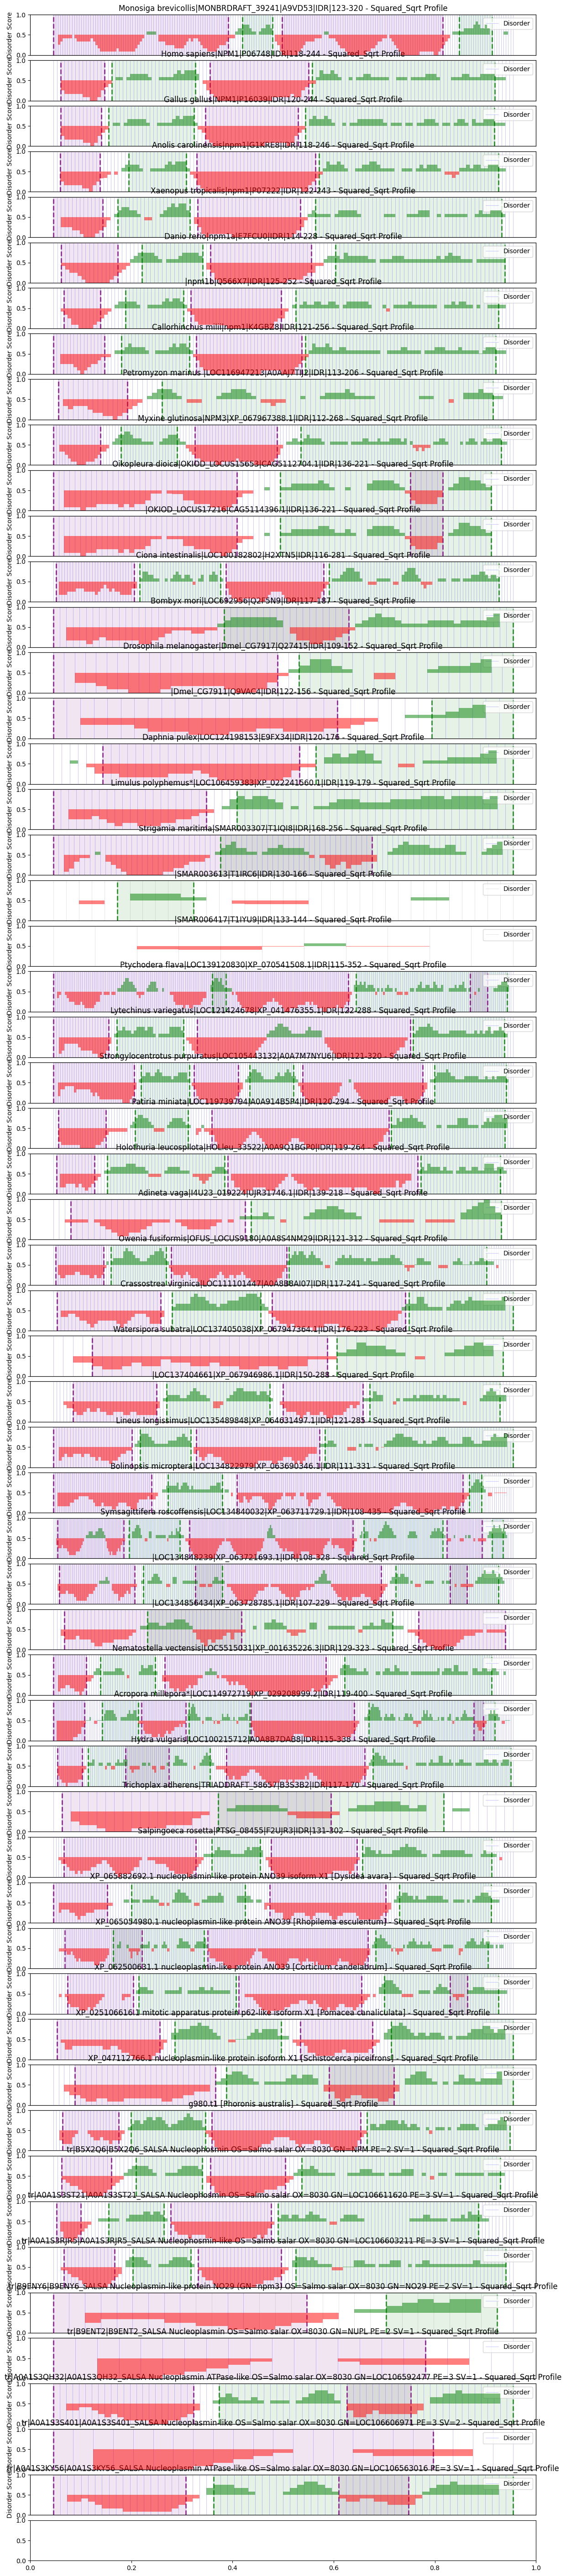

In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# PARAMETERS
threshold_positive = 1.0  # Threshold for positive IDR detection
threshold_negative = 1.0  # Threshold for negative IDR detection
min_length = 7          # Minimum length for IDR regions
pH = 7.2                # pH for charge calculation
max_gap = 20            # Maximum gap to connect similar charge IDRs
charge_window_size = 6  # Sliding window size for charge/NCPR calculation
max_region_length = 70  # Maximum length of regions to analyze

# Read clustered fasta file
names = []
sequences = []
file_path = "/home/ilnitsky/NPM/45_Species/fasta_sequences/Zoopark_Domains_NPM_IDR.fasta"
with open(file_path, "r") as f: 
    lines = f.readlines()
    for line in lines:
        if line.startswith(">"):
            names.append(line.strip().lstrip(">"))
        else:
            sequences.append(line.strip())

sequences4plot = sequences
names4plot = names

# Function to calculate cumulative charge array
def calculate_cumulative_charge(sequence, pH=pH):
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    cumulative_charge = np.zeros(len(sequence) + 1)
    for i, aa in enumerate(sequence, 1):
        charge = 0.0
        if aa in pKa_values:
            if aa in ['D', 'E', 'H', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                charge -= fraction_deprotonated
            elif aa in ['K', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                charge += fraction_protonated
        cumulative_charge[i] = cumulative_charge[i-1] + charge
    return cumulative_charge

# FUNCTION TO GET IDR REGIONS AND METRIC PROFILES
def get_idr_regions_and_profiles(sequence, threshold_positive=threshold_positive, threshold_negative=threshold_negative, min_length=min_length, pH=pH, max_gap=max_gap, charge_window_size=charge_window_size, max_region_length=max_region_length):
    max_len = len(sequence)
    idr_regions = {"squared_sqrt": {"positive": [], "negative": []}}
    profiles = {
        'squared_sqrt': np.zeros(max_len)
    }
    
    # Precompute cumulative charge
    cumulative_charge = calculate_cumulative_charge(sequence)
    
    # Calculate NCPR with sliding window
    ncpr_x = []
    ncpr_y = []
    for i in range(max_len - charge_window_size + 1):
        window_start = i + 1
        window_end = i + charge_window_size
        charge = cumulative_charge[window_end] - cumulative_charge[window_start - 1]
        ncpr = charge / charge_window_size
        ncpr_x.append(window_start + (charge_window_size - 1) / 2)  # Center of window
        ncpr_y.append(ncpr)
    
    # Calculate metrics for regions up to max_region_length
    for start in range(1, max_len + 1):
        for length in range(min_length, min(max_region_length + 1, max_len - start + 2)):
            end = start + length - 1
            charge = cumulative_charge[end] - cumulative_charge[start - 1]
            region_seq = sequence[start-1:end]
            
            # Compute squared_sqrt metric only
            metric_value = (charge ** 2) / np.sqrt(length)
            
            if charge > 0 and metric_value > profiles['squared_sqrt'][start-1]:
                profiles['squared_sqrt'][start-1] = metric_value
            elif charge < 0 and metric_value > profiles['squared_sqrt'][start-1]:
                profiles['squared_sqrt'][start-1] = metric_value
            
            # IDR detection based on squared_sqrt profile value with separate thresholds
            if charge > 0 and metric_value > threshold_positive:
                idr_regions["squared_sqrt"]["positive"].append((start, end, region_seq, metric_value))
            elif charge < 0 and metric_value > threshold_negative:
                idr_regions["squared_sqrt"]["negative"].append((start, end, region_seq, metric_value))
    
    # Debug: Check if IDRs were detected
    if not idr_regions["squared_sqrt"]["positive"] and not idr_regions["squared_sqrt"]["negative"]:
        print(f"Warning: No IDRs detected for {sequence[:20]}... (len={len(sequence)}) using squared_sqrt metric. Check charge distribution or thresholds ({threshold_positive}/{threshold_negative}) at pH {pH}.")
    
    # Filter out overlapping and handle nested splitting
    def filter_and_split_regions(pos_regions, neg_regions):
        all_regions = pos_regions + neg_regions
        non_overlapping = []
        
        while all_regions:
            r1 = max(all_regions, key=lambda x: x[3])  # Select region with highest metric
            all_regions.remove(r1)
            start1, end1, seq1, metric1 = r1
            overlap = False
            
            for r2 in non_overlapping:
                start2, end2, _, _ = r2
                if not (end1 < start2 or start1 > end2):  # Check for overlap
                    overlap = True
                    # If r1 is larger and contains r2 of opposite charge, split r1
                    if (start1 <= start2 and end1 >= end2) and (
                        (r1 in pos_regions and r2 in neg_regions) or (r1 in neg_regions and r2 in pos_regions)
                    ):
                        if start1 < start2:
                            new_seq = sequence[start1-1:start2-1]
                            new_charge = cumulative_charge[start2-1] - cumulative_charge[start1-1]
                            new_length = start2 - start1
                            new_metric = (new_charge ** 2) / np.sqrt(new_length)
                            if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                all_regions.append((start1, start2-1, new_seq, new_metric))
                        if end1 > end2:
                            new_seq = sequence[end2-1:end1]
                            new_charge = cumulative_charge[end1] - cumulative_charge[end2-1]
                            new_length = end1 - end2 + 1
                            new_metric = (new_charge ** 2) / np.sqrt(new_length)
                            if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                all_regions.append((end2, end1, new_seq, new_metric))
                    break
            
            if not overlap:
                non_overlapping.append(r1)
        
        return {'positive': [r for r in non_overlapping if r in pos_regions], 
                'negative': [r for r in non_overlapping if r in neg_regions]}

    idr_regions["squared_sqrt"] = filter_and_split_regions(idr_regions["squared_sqrt"]["positive"], idr_regions["squared_sqrt"]["negative"])
    
    # Connect similar charge IDRs if gap is less than max_gap
    pos_regions = idr_regions["squared_sqrt"]["positive"]
    neg_regions = idr_regions["squared_sqrt"]["negative"]
    
    # Sort regions by start position
    pos_regions.sort(key=lambda x: x[0])
    neg_regions.sort(key=lambda x: x[0])
    
    # Connect positive regions
    i = 0
    while i < len(pos_regions) - 1:
        curr_end = pos_regions[i][1]
        next_start = pos_regions[i + 1][0]
        if next_start - curr_end <= max_gap:
            new_start = pos_regions[i][0]
            new_end = pos_regions[i + 1][1]
            new_seq = sequence[new_start-1:new_end]
            new_metric = max(pos_regions[i][3], pos_regions[i + 1][3])  # Use max metric value
            pos_regions[i] = (new_start, new_end, new_seq, new_metric)
            pos_regions.pop(i + 1)
        else:
            i += 1
    
    # Connect negative regions
    i = 0
    while i < len(neg_regions) - 1:
        curr_end = neg_regions[i][1]
        next_start = neg_regions[i + 1][0]
        if next_start - curr_end <= max_gap:
            new_start = neg_regions[i][0]
            new_end = neg_regions[i + 1][1]
            new_seq = sequence[new_start-1:new_end]
            new_metric = max(neg_regions[i][3], neg_regions[i + 1][3])  # Use max metric value
            neg_regions[i] = (new_start, new_end, new_seq, new_metric)
            neg_regions.pop(i + 1)
        else:
            i += 1
    
    idr_regions["squared_sqrt"]["positive"] = pos_regions
    idr_regions["squared_sqrt"]["negative"] = neg_regions
    
    return idr_regions, profiles, ncpr_x, ncpr_y

# Function to calculate net charge for a region using pKa and pH (used for validation, can be removed if cumulative_charge is sufficient)
def calculate_net_charge(sequence, start, end, pH=pH):
    region = sequence[start-1:end]  # 0-based indexing adjustment
    net_charge = 0.0
    
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 8.5,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    
    for aa in region:
        if aa in pKa_values:
            if aa in ['D', 'E', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                net_charge -= fraction_deprotonated
            elif aa in ['K', 'H', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                net_charge += fraction_protonated
    
    return net_charge

fig, axs = plt.subplots(len(sequences4plot), 1, figsize=(12, 4*len(sequences4plot)), squeeze=False)
axs = axs.ravel()

# PRINT SECTIONS
print("="*80)
print(f"IDR REGIONS (Positive Threshold={threshold_positive}, Negative Threshold={threshold_negative} for squared_sqrt metric, Min Length={min_length}aa, pH={pH}, Max Gap={max_gap}, Charge Window Size={charge_window_size}, Max Region Length={max_region_length})")
print("="*80)

for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(f"\n{name}")
    print("-"*len(name))
    
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
    except:
        print(f"Error with sequence {i}: {name}")
        continue
    
    # Print IDR regions for squared_sqrt metric
    print(f"\nSQUARED_SQRT Metric IDRs:")
    if idr_regions["squared_sqrt"]["positive"]:
        for start, end, seq_region, metric in idr_regions["squared_sqrt"]["positive"]:
            print(f"+IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")
    if idr_regions["squared_sqrt"]["negative"]:
        for start, end, seq_region, metric in idr_regions["squared_sqrt"]["negative"]:
            print(f"-IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")

print("\n" + "="*80)

# PLOTTING
for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(i, name)
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    positions = range(1, len(sequence) + 1)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
    except:
        print(f"Error with sequence {i}: {name}")
        continue

    # Plot for squared_sqrt metric profile
    ax = axs[i]

    # PLOT 2: VERTICAL LINES for disorder (individual disorder >0.6 = blue)
    for pos, disorder in zip(positions, disorder_prediction):
        color = 'blue' if disorder > 0.6 else 'gray'
        alpha = 0.3
        ax.axvline(x=pos, color=color, alpha=alpha, linewidth=0.5)

    # PLOT 4: IDR BORDERS specific to squared_sqrt metric
    for start, end, _, _ in idr_regions["squared_sqrt"]["positive"]:
        ax.axvline(x=start, color='green', linewidth=2, alpha=0.8, linestyle='--')
        ax.axvline(x=end, color='green', linewidth=2, alpha=0.8, linestyle='--')
        ax.axvspan(start, end, color='green', alpha=0.1)
    for start, end, _, _ in idr_regions["squared_sqrt"]["negative"]:
        ax.axvline(x=start, color='purple', linewidth=2, alpha=0.8, linestyle='--')
        ax.axvline(x=end, color='purple', linewidth=2, alpha=0.8, linestyle='--')
        ax.axvspan(start, end, color='purple', alpha=0.1)

    # PLOT 5: NCPR (bars) for reference
    ax2 = ax.twinx()
    for x, y in zip(ncpr_x, ncpr_y):
        color = 'green' if y >= 0 else 'red'
        ax2.bar(x, y, width=1, color=color, alpha=0.5, align='center')

    # Set axis properties
    ax.set_ylim([0, 1])  # Adjusted to focus on disorder and IDR visualization
    ax2.set_ylim([-1.0, 1.0])
    ax.set_xticks([])
    ax2.set_xticks([])
    ax.set_yticks([0, 0.5, 1])
    ax2.set_yticks([])
    
    ax.set_title(f'{name} - Squared_Sqrt Profile')
    ax.set_ylabel('Disorder Score', color='black')
    ax.legend(['Disorder'], loc='upper right')

plt.tight_layout()
plt.gcf().set_size_inches(12, 1*len(sequences4plot))

plt.show()

In [15]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# PARAMETERS
threshold_positive = 1.0  # Threshold for positive IDR detection
threshold_negative = 1.0  # Threshold for negative IDR detection
min_length = 7          # Minimum length for IDR regions
pH = 7.0                # pH for charge calculation
max_gap = 20            # Maximum gap to connect similar charge IDRs
charge_window_size = 6  # Sliding window size for charge/NCPR calculation
max_region_length = 80  # Maximum length of regions to analyze

# Read clustered fasta file
names = []
sequences = []
file_path = "/home/ilnitsky/NPM/45_Species/fasta_sequences/Zoopark_Domains_NPM_IDR.fasta"
with open(file_path, "r") as f: 
    lines = f.readlines()
    for line in lines:
        if line.startswith(">"):
            names.append(line.strip().lstrip(">"))
        else:
            sequences.append(line.strip())

sequences4plot = sequences
names4plot = names

# Function to calculate cumulative charge array
def calculate_cumulative_charge(sequence, pH=pH):
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    cumulative_charge = np.zeros(len(sequence) + 1)
    for i, aa in enumerate(sequence, 1):
        charge = 0.0
        if aa in pKa_values:
            if aa in ['D', 'E', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                charge -= fraction_deprotonated
            elif aa in ['K', 'H', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                charge += fraction_protonated
        cumulative_charge[i] = cumulative_charge[i-1] + charge
    return cumulative_charge

# FUNCTION TO GET IDR REGIONS AND METRIC PROFILES
def get_idr_regions_and_profiles(sequence, threshold_positive=threshold_positive, threshold_negative=threshold_negative, min_length=min_length, pH=pH, max_gap=max_gap, charge_window_size=charge_window_size, max_region_length=max_region_length):
    max_len = len(sequence)
    idr_regions = {"sqrt": {"positive": [], "negative": []},
                   "squared_sqrt": {"positive": [], "negative": []},
                   "cbrt": {"positive": [], "negative": []}}
    profiles = {
        'sqrt': np.zeros(max_len),
        'squared_sqrt': np.zeros(max_len),
        'cbrt': np.zeros(max_len)
    }
    
    # Precompute cumulative charge
    cumulative_charge = calculate_cumulative_charge(sequence)
    
    # Calculate NCPR with sliding window
    ncpr_x = []
    ncpr_y = []
    for i in range(max_len - charge_window_size + 1):
        window_start = i + 1
        window_end = i + charge_window_size
        charge = cumulative_charge[window_end] - cumulative_charge[window_start - 1]
        ncpr = charge / charge_window_size
        ncpr_x.append(window_start + (charge_window_size - 1) / 2)  # Center of window
        ncpr_y.append(ncpr)
    
    # Calculate metrics for regions up to max_region_length
    for start in range(1, max_len + 1):
        for length in range(min_length, min(max_region_length + 1, max_len - start + 2)):
            end = start + length - 1
            charge = cumulative_charge[end] - cumulative_charge[start - 1]
            region_seq = sequence[start-1:end]
            
            # Compute all metrics
            metrics = {
                'sqrt': abs(charge) / np.sqrt(length),
                'squared_sqrt': (charge ** 2) / np.sqrt(length),
                'cbrt': abs(charge) / (length ** (1/3))
            }
            for metric_name, metric_value in metrics.items():
                if charge > 0 and metric_value > profiles[metric_name][start-1]:
                    profiles[metric_name][start-1] = metric_value
                elif charge < 0 and metric_value > profiles[metric_name][start-1]:
                    profiles[metric_name][start-1] = metric_value
                
                # IDR detection based on each metric's profile value with separate thresholds
                if charge > 0 and metric_value > threshold_positive:
                    idr_regions[metric_name]["positive"].append((start, end, region_seq, metric_value))
                elif charge < 0 and metric_value > threshold_negative:
                    idr_regions[metric_name]["negative"].append((start, end, region_seq, metric_value))
    
    # Debug: Check if IDRs were detected for any metric
    for metric_name in idr_regions:
        if not idr_regions[metric_name]["positive"] and not idr_regions[metric_name]["negative"]:
            print(f"Warning: No IDRs detected for {sequence[:20]}... (len={len(sequence)}) using {metric_name} metric. Check charge distribution or thresholds ({threshold_positive}/{threshold_negative}) at pH {pH}.")
    
    # Filter out overlapping and handle nested splitting for each metric
    for metric_name in idr_regions:
        def filter_and_split_regions(pos_regions, neg_regions):
            all_regions = pos_regions + neg_regions
            non_overlapping = []
            
            while all_regions:
                r1 = max(all_regions, key=lambda x: x[3])  # Select region with highest metric
                all_regions.remove(r1)
                start1, end1, seq1, metric1 = r1
                overlap = False
                
                for r2 in non_overlapping:
                    start2, end2, _, _ = r2
                    if not (end1 < start2 or start1 > end2):  # Check for overlap
                        overlap = True
                        # If r1 is larger and contains r2 of opposite charge, split r1
                        if (start1 <= start2 and end1 >= end2) and (
                            (r1 in pos_regions and r2 in neg_regions) or (r1 in neg_regions and r2 in pos_regions)
                        ):
                            if start1 < start2:
                                new_seq = sequence[start1-1:start2-1]
                                new_charge = cumulative_charge[start2-1] - cumulative_charge[start1-1]
                                new_length = start2 - start1
                                new_metric = (new_charge ** 2) / np.sqrt(new_length) if metric_name == 'squared_sqrt' else abs(new_charge) / (np.sqrt(new_length) if metric_name == 'sqrt' else new_length ** (1/3) if metric_name == 'cbrt' else new_length)
                                if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                    all_regions.append((start1, start2-1, new_seq, new_metric))
                            if end1 > end2:
                                new_seq = sequence[end2-1:end1]
                                new_charge = cumulative_charge[end1] - cumulative_charge[end2-1]
                                new_length = end1 - end2 + 1
                                new_metric = (new_charge ** 2) / np.sqrt(new_length) if metric_name == 'squared_sqrt' else abs(new_charge) / (np.sqrt(new_length) if metric_name == 'sqrt' else new_length ** (1/3) if metric_name == 'cbrt' else new_length)
                                if new_metric > (threshold_positive if new_charge > 0 else threshold_negative) and len(new_seq) >= min_length:
                                    all_regions.append((end2, end1, new_seq, new_metric))
                        break
                
                if not overlap:
                    non_overlapping.append(r1)
            
            return {'positive': [r for r in non_overlapping if r in pos_regions], 
                    'negative': [r for r in non_overlapping if r in neg_regions]}

        idr_regions[metric_name] = filter_and_split_regions(idr_regions[metric_name]["positive"], idr_regions[metric_name]["negative"])
    
    # Connect similar charge IDRs if gap is less than max_gap
    for metric_name in idr_regions:
        pos_regions = idr_regions[metric_name]["positive"]
        neg_regions = idr_regions[metric_name]["negative"]
        
        # Sort regions by start position
        pos_regions.sort(key=lambda x: x[0])
        neg_regions.sort(key=lambda x: x[0])
        
        # Connect positive regions
        i = 0
        while i < len(pos_regions) - 1:
            curr_end = pos_regions[i][1]
            next_start = pos_regions[i + 1][0]
            if next_start - curr_end <= max_gap:
                new_start = pos_regions[i][0]
                new_end = pos_regions[i + 1][1]
                new_seq = sequence[new_start-1:new_end]
                new_metric = max(pos_regions[i][3], pos_regions[i + 1][3])  # Use max metric value
                pos_regions[i] = (new_start, new_end, new_seq, new_metric)
                pos_regions.pop(i + 1)
            else:
                i += 1
        
        # Connect negative regions
        i = 0
        while i < len(neg_regions) - 1:
            curr_end = neg_regions[i][1]
            next_start = neg_regions[i + 1][0]
            if next_start - curr_end <= max_gap:
                new_start = neg_regions[i][0]
                new_end = neg_regions[i + 1][1]
                new_seq = sequence[new_start-1:new_end]
                new_metric = max(neg_regions[i][3], neg_regions[i + 1][3])  # Use max metric value
                neg_regions[i] = (new_start, new_end, new_seq, new_metric)
                neg_regions.pop(i + 1)
            else:
                i += 1
        
        idr_regions[metric_name]["positive"] = pos_regions
        idr_regions[metric_name]["negative"] = neg_regions
    
    return idr_regions, profiles, ncpr_x, ncpr_y

# Function to calculate net charge for a region using pKa and pH (used for validation, can be removed if cumulative_charge is sufficient)
def calculate_net_charge(sequence, start, end, pH=pH):
    region = sequence[start-1:end]  # 0-based indexing adjustment
    net_charge = 0.0
    
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    
    for aa in region:
        if aa in pKa_values:
            if aa in ['D', 'E', 'H', 'C', 'Y']:
                fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
                net_charge -= fraction_deprotonated
            elif aa in ['K', 'R']:
                fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
                net_charge += fraction_protonated
    
    return net_charge

fig, axs = plt.subplots(len(sequences4plot), 3, figsize=(36, 4*len(sequences4plot)), squeeze=False)  # Changed to 3 columns
axs = axs.ravel()

# PRINT SECTIONS
print("="*80)
print(f"IDR REGIONS (Positive Threshold={threshold_positive}, Negative Threshold={threshold_negative} for each metric, Min Length={min_length}aa, pH={pH}, Max Gap={max_gap}, Charge Window Size={charge_window_size}, Max Region Length={max_region_length})")
print("="*80)

for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(f"\n{name}")
    print("-"*len(name))
    
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
    except:
        print(f"Error with sequence {i}: {name}")
        continue
    
    # Print IDR regions for each metric
    for metric_name in idr_regions:
        print(f"\n{metric_name.upper()} Metric IDRs:")
        if idr_regions[metric_name]["positive"]:
            for start, end, seq_region, metric in idr_regions[metric_name]["positive"]:
                print(f"+IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")
        if idr_regions[metric_name]["negative"]:
            for start, end, seq_region, metric in idr_regions[metric_name]["negative"]:
                print(f"-IDR {start}-{end} (Metric: {metric:.2f}) {seq_region}")

print("\n" + "="*80)

# PLOTTING
for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    print(i, name)
    disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
    positions = range(1, len(sequence) + 1)
    
    # Get NCPR data and IDR regions with profiles
    try:
        idr_regions, profiles, ncpr_x, ncpr_y = get_idr_regions_and_profiles(sequence)
    except:
        print(f"Error with sequence {i}: {name}")
        continue

    # Plot for each metric profile
    for j, metric_name in enumerate(['sqrt', 'squared_sqrt', 'cbrt']):
        ax = axs[i * 3 + j]  # Adjusted indexing for 3 columns

        # PLOT 2: VERTICAL LINES for disorder (individual disorder >0.6 = blue)
        for pos, disorder in zip(positions, disorder_prediction):
            color = 'blue' if disorder > 0.6 else 'gray'
            alpha = 0.3
            ax.axvline(x=pos, color=color, alpha=alpha, linewidth=0.5)

        # PLOT 4: IDR BORDERS specific to each metric
        for start, end, _, _ in idr_regions[metric_name]["positive"]:
            ax.axvline(x=start, color='green', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvline(x=end, color='green', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvspan(start, end, color='green', alpha=0.1)
        for start, end, _, _ in idr_regions[metric_name]["negative"]:
            ax.axvline(x=start, color='purple', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvline(x=end, color='purple', linewidth=2, alpha=0.8, linestyle='--')
            ax.axvspan(start, end, color='purple', alpha=0.1)

        # PLOT 5: NCPR (bars) for reference
        ax2 = ax.twinx()
        for x, y in zip(ncpr_x, ncpr_y):
            color = 'green' if y >= 0 else 'red'
            ax2.bar(x, y, width=1, color=color, alpha=0.5, align='center')

        # Set axis properties
        ax.set_ylim([0, 1])  # Adjusted to focus on disorder and IDR visualization
        ax2.set_ylim([-1.0, 1.0])
        ax.set_xticks([])
        ax2.set_xticks([])
        ax.set_yticks([0, 0.5, 1])
        ax2.set_yticks([])
        
        ax.set_title(f'{name} - {metric_name.capitalize()} Profile')
        ax.set_ylabel('Disorder Score', color='black')
        if j == 0:
            ax.legend(['Disorder'], loc='upper right')

plt.tight_layout()
plt.gcf().set_size_inches(36, 4*len(sequences4plot))  # Adjusted for 3 plots per row

plt.show()

IDR REGIONS (Positive Threshold=1.0, Negative Threshold=1.0 for each metric, Min Length=7aa, pH=7.0, Max Gap=20, Charge Window Size=6, Max Region Length=80)

Monosiga brevicollis|MONBRDRAFT_39241|A9VD53|IDR|123-320
--------------------------------------------------------

SQRT Metric IDRs:
+IDR 82-95 (Metric: 1.60) KRGKGASNSNKRAK
+IDR 180-189 (Metric: 1.58) KKAAKKTAAK
-IDR 19-76 (Metric: 3.92) DSDDEDESDEDDLDDDDHLDSQTGRVVTLEDSSDQEDDVDSPIIEVLEDDDDLEEAPE
-IDR 97-168 (Metric: 5.77) DEEDDEEDEEDDVAGQEESKLQLTMDVMEDEDDEDDEDDEDAELDLSMTVPDDEDDEDDEDDEELDDDEEED

SQUARED_SQRT Metric IDRs:
+IDR 82-95 (Metric: 9.62) KRGKGASNSNKRAK
+IDR 175-189 (Metric: 9.29) KTPVTKKAAKKTAAK
-IDR 2-76 (Metric: 124.04) EQVQETMMQLQEHGILGDSDDEDESDEDDLDDDDHLDSQTGRVVTLEDSSDQEDDVDSPIIEVLEDDDDLEEAPE
-IDR 97-168 (Metric: 282.20) DEEDDEEDEEDDVAGQEESKLQLTMDVMEDEDDEDDEDDEDAELDLSMTVPDDEDDEDDEDDEELDDDEEED

CBRT Metric IDRs:
+IDR 82-95 (Metric: 2.49) KRGKGASNSNKRAK
+IDR 175-189 (Metric: 2.43) KTPVTKKAAKKTAAK
-IDR 2-76 (Metric: 7.77

In [16]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from reportlab.lib.colors import Color
import os

# Define colors for amino acid charges
def get_amino_acid_color(aa, pH=7.0):
    pKa_values = {
        'D': 3.9,  # Aspartic acid
        'E': 4.3,  # Glutamic acid
        'H': 6.0,  # Histidine
        'C': 8.3,  # Cysteine
        'Y': 10.1, # Tyrosine
        'K': 10.5, # Lysine
        'R': 12.5  # Arginine
    }
    if aa in pKa_values:
        if aa in ['D', 'E', 'C', 'Y']:
            fraction_deprotonated = 1 / (1 + 10**(pKa_values[aa] - pH))
            if fraction_deprotonated > 0.5:  # Considered negatively charged
                return Color(1, 0, 0)  # Red for negative
        elif aa in ['K', 'H', 'R']:
            fraction_protonated = 1 / (1 + 10**(pH - pKa_values[aa]))
            if fraction_protonated > 0.5:  # Considered positively charged
                return Color(0, 0, 1)  # Blue for positive
    return Color(0, 0, 0)  # Black for neutral

# Function to draw a sequence with colored amino acids
def draw_colored_sequence(c, sequence, x, y, font_size, char_width):
    for i, aa in enumerate(sequence):
        c.setFillColor(get_amino_acid_color(aa))
        c.drawString(x + i * char_width, y, aa)
    c.setFillColor(Color(0, 0, 0))  # Reset to black

# Create PDF
output_pdf = "protein_idr_sequences.pdf"
c = canvas.Canvas(output_pdf, pagesize=letter)
width, height = letter
margin = 0.5 * inch
max_width = width - 2 * margin
font_size = 10
char_width = 6  # Approximate width per character in Courier
line_spacing = 15

for i, (sequence, name) in enumerate(zip(sequences4plot, names4plot)):
    # Start a new page for each protein
    c.setFont("Courier", font_size)  # Use Courier (monospaced, no TTF)
    
    # Calculate IDR regions
    try:
        idr_regions, _, _, _ = get_idr_regions_and_profiles(sequence)
    except Exception as e:
        print(f"Error processing {name}: {e}")
        continue
    
    # Calculate scaling to fit sequence
    seq_length = len(sequence)
    total_width = seq_length * char_width
    scale = min(1, max_width / total_width) if total_width > max_width else 1
    adjusted_char_width = char_width * scale
    adjusted_font_size = font_size * scale
    
    # Draw protein name
    y = height - margin
    c.setFont("Courier", 12)
    c.drawString(margin, y, name)
    y -= 2 * line_spacing
    
    # Draw full sequence
    c.setFont("Courier", adjusted_font_size)
    draw_colored_sequence(c, sequence, margin, y, adjusted_font_size, adjusted_char_width)
    y -= line_spacing
    
    # First draw all IDR regions for each metric
    for metric_name in ['sqrt', 'squared_sqrt', 'cbrt']:
        c.setFont("Courier", adjusted_font_size)
        
        # Draw positive IDRs
        for start, end, seq_region, _ in idr_regions[metric_name]["positive"]:
            x_start = margin + (start - 1) * adjusted_char_width
            draw_colored_sequence(c, seq_region, x_start, y, adjusted_font_size, adjusted_char_width)
        
        # Draw negative IDRs
        for start, end, seq_region, _ in idr_regions[metric_name]["negative"]:
            x_start = margin + (start - 1) * adjusted_char_width
            draw_colored_sequence(c, seq_region, x_start, y, adjusted_font_size, adjusted_char_width)
        
        y -= line_spacing
    
    # Now add metric annotations below all the IDR sequences
    y -= line_spacing  # Add some extra space
    y -= line_spacing
    c.setFont("Courier", adjusted_font_size)
    c.drawString(margin, y, f"LEGEND")
    y -= line_spacing
    for metric_name in ['sqrt', 'squared_sqrt', 'cbrt']:
        c.drawString(margin, y, f"{metric_name}:")
        y -= line_spacing
    
    c.showPage()

c.save()
print(f"PDF saved as {output_pdf}")

PDF saved as protein_idr_sequences.pdf
